# Fine-tuning on Pre-trained Model for Cell-type Annotation
In this tutorial, we demonstrate how to fine-tune a pre-trained model on a new dataset for the cell type annotation task. We use the Multiple Sclerosis dataset as an example and fine-tune on the pre-trained whole-body model. Please download the dataset folder from https://drive.google.com/drive/folders/1Qd42YNabzyr2pWt9xoY4cVMTAxsNBt4v?usp=sharing

We summarize the fine-tuning pipeline in the following steps, which can be used as a general recipe for finetuning on cell-type annotation tasks and beyond: 

     1. Specify hyper-parameter setup for integration task
     
     2. Load and pre-process data
     
     3. Load the pre-trained scGPT model
     
     4. Finetune scGPT with task-specific objectives
     
     5. Evaluate fine-tuned scGPT

## Step 0: Load and install packages

In [1]:
# !pip install mygene
!export http_proxy=http://proxy.nhr.fau.de:80
!export https_proxy=http://proxy.nhr.fau.de:80

In [2]:
# %%
import copy
import gc
import json
import os
from pathlib import Path
import shutil
import sys
import time
import traceback
from typing import List, Tuple, Dict, Union, Optional
import warnings
import pandas as pd
# from . import asyn
import pickle
import torch
from anndata import AnnData
import scanpy as sc
# import scvi
import seaborn as sns
import numpy as np
import wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from torchtext.vocab import Vocab
from torchtext._torchtext import (
    Vocab as VocabPybind,
)
from sklearn.metrics import confusion_matrix

sys.path.insert(0, "../")
import scgpt as scg
from scgpt.model import TransformerModel, AdversarialDiscriminator
from scgpt.tokenizer import tokenize_and_pad_batch, random_mask_value
from scgpt.loss import (
    masked_mse_loss,
    masked_relative_error,
    criterion_neg_log_bernoulli,
)
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.preprocess import Preprocessor
from scgpt import SubsetsBatchSampler
from scgpt.utils import set_seed, category_str2int, eval_scib_metrics

sc.set_figure_params(figsize=(6, 6))
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')

/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packag

In [3]:
!which python

/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/bin/python


In [4]:
# !pip install -U scgpt "torch<=2.2.2" "numpy<2" "umap-learn<0.5.7"
# !pip install wandb louvain
# !pip install lightgbm
# !pip install scgpt "flash-attn<1.0.5"  # optional, recommended
# !pip install -U "torch<=2.2.2" torchvision torchaudio
# !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.2.0+cu121.html
# !pip install torch_geometric
# !pip install nbformat
## Restate kernel after installation

In [5]:
# !pip install -q -U gdown
# import gdown
# gdown.download_folder(
#     "https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y",
#     output='/home/tttoan_hoandv/research/scGPT/models/scGPT_human',
# )
# gdown.download_folder(
#     "https://drive.google.com/drive/folders/1hZLz8aEsv5_VeTt8LtrvZ66fLFWp0fMP?usp=sharing",
#     output='/home/tttoan_hoandv/research/scGPT/data',
# )

In [6]:
from scipy.spatial import cKDTree
from scipy.stats import mode
from collections import Counter
def cKD_refine_label(coords, labels, k):
    # Step 1: Build KD-Tree
    tree = cKDTree(coords.copy())

    # Step 2: Find k-nearest neighbors for each spot
    # k+1 because the closest point is itself
    distances, neighbors = tree.query(coords, k=k+1)

    # Exclude self-neighbor (first column)
    neighbors = neighbors[:, 1:]

    # Step 3: Reassign labels
    new_labels = labels.copy()
    for i, nbrs in enumerate(neighbors):
        # Get the labels of neighboring spots
        neighbor_labels = labels[nbrs]
        # Find the most common label among neighbors
        # most_common_label = mode(neighbor_labels).mode[0]
        most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
        # Reassign the label
        new_labels[i] = most_common_label
    return (new_labels)

## Step 1: Specify hyper-parameter setup for cell-type annotation task
Listed below are some hyper-parameter recommendations for the cell-type task. Note that the CLS objective is on to facilitate cell-type classification.

In [7]:
hyperparameter_defaults = dict(
    seed=123,
    dataset_name="ms",
    do_train=True,
    load_model="/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human",
    mask_ratio=0.0,
    epochs=20, #20
    n_bins=51,
    MVC=False, # Masked value prediction for cell embedding
    ecs_thres=0.0, # Elastic cell similarity objective, 0.0 to 1.0, 0.0 to disable
    dab_weight=0.0,
    lr=1e-4,
    batch_size=16, #32
    layer_size=128, # 128
    nlayers=4,  # number of nn.TransformerEncoderLayer in nn.TransformerEncoder
    nhead=4,  # number of heads in nn.MultiheadAttention
    dropout=0.2,  # dropout probability
    schedule_ratio=0.9,  # ratio of epochs for learning rate schedule
    save_eval_interval=5,
    fast_transformer=True,
    pre_norm=False,
    amp=True,  # Automatic Mixed Precision
    include_zero_gene = False,
    freeze = True, #freeze: False
    DSBN = False,  # Domain-spec batchnorm
)

In [8]:
# key: eae607e6e500c13c75854f5b95b9a488c9934aa6

In [9]:
import os
os.environ["WANDB_MODE"] = "offline"  # Force offline mode
import wandb
run = wandb.init(
    config=hyperparameter_defaults,
    project="scGPT",
    reinit=True,
    name="finetune-scgpt-run1",
    settings=wandb.Settings(start_method="fork"),
)
config = wandb.config
print(config)

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


{'seed': 123, 'dataset_name': 'ms', 'do_train': True, 'load_model': '/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human', 'mask_ratio': 0, 'epochs': 20, 'n_bins': 51, 'MVC': False, 'ecs_thres': 0, 'dab_weight': 0, 'lr': 0.0001, 'batch_size': 16, 'layer_size': 128, 'nlayers': 4, 'nhead': 4, 'dropout': 0.2, 'schedule_ratio': 0.9, 'save_eval_interval': 5, 'fast_transformer': True, 'pre_norm': False, 'amp': True, 'include_zero_gene': False, 'freeze': True, 'DSBN': False}


In [10]:
# settings for input and preprocessing
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
mask_ratio = config.mask_ratio
mask_value = "auto"  # for masked values, now it should always be auto

include_zero_gene = config.include_zero_gene  # if True, include zero genes among hvgs in the training
max_seq_len = 3001
n_bins = config.n_bins

# input/output representation
input_style = "binned"  # "normed_raw", "log1p", or "binned"
output_style = "binned"  # "normed_raw", "log1p", or "binned"

# settings for training
MLM = False  # whether to use masked language modeling, currently it is always on.
CLS = True  # celltype classification objective
ADV = False  # Adversarial training for batch correction
CCE = False  # Contrastive cell embedding objective
MVC = config.MVC  # Masked value prediction for cell embedding
ECS = config.ecs_thres > 0  # Elastic cell similarity objective
DAB = False  # Domain adaptation by reverse backpropagation, set to 2 for separate optimizer
INPUT_BATCH_LABELS = False  # TODO: have these help MLM and MVC, while not to classifier
input_emb_style = "continuous"  # "category" or "continuous" or "scaling"
cell_emb_style = "cls"  # "avg-pool" or "w-pool" or "cls"
adv_E_delay_epochs = 0  # delay adversarial training on encoder for a few epochs
adv_D_delay_epochs = 0
mvc_decoder_style = "inner product"
ecs_threshold = config.ecs_thres
dab_weight = config.dab_weight

explicit_zero_prob = MLM and include_zero_gene  # whether explicit bernoulli for zeros
do_sample_in_train = False and explicit_zero_prob  # sample the bernoulli in training

per_seq_batch_sample = False

# settings for optimizer
lr = config.lr  # TODO: test learning rate ratio between two tasks
lr_ADV = 1e-3  # learning rate for discriminator, used when ADV is True
batch_size = config.batch_size
eval_batch_size = config.batch_size
epochs = config.epochs
schedule_interval = 1

# settings for the model
fast_transformer = config.fast_transformer
fast_transformer_backend = "flash"  # "linear" or "flash"
embsize = config.layer_size  # embedding dimension
d_hid = config.layer_size  # dimension of the feedforward network in TransformerEncoder
nlayers = config.nlayers  # number of TransformerEncoderLayer in TransformerEncoder
nhead = config.nhead  # number of heads in nn.MultiheadAttention
dropout = config.dropout  # dropout probability

# logging
log_interval = 100  # iterations
save_eval_interval = config.save_eval_interval  # epochs
do_eval_scib_metrics = True

In [11]:
# %% validate settings
assert input_style in ["normed_raw", "log1p", "binned"]
assert output_style in ["normed_raw", "log1p", "binned"]
assert input_emb_style in ["category", "continuous", "scaling"]
if input_style == "binned":
    if input_emb_style == "scaling":
        raise ValueError("input_emb_style `scaling` is not supported for binned input.")
elif input_style == "log1p" or input_style == "normed_raw":
    if input_emb_style == "category":
        raise ValueError(
            "input_emb_style `category` is not supported for log1p or normed_raw input."
        )

if input_emb_style == "category":
    mask_value = n_bins + 1
    pad_value = n_bins  # for padding gene expr values
    n_input_bins = n_bins + 2
else:
    mask_value = -1
    pad_value = -2
    n_input_bins = n_bins

if ADV and DAB:
    raise ValueError("ADV and DAB cannot be both True.")
DAB_separate_optim = True if DAB > 1 else False

In [12]:
dataset_name = config.dataset_name
save_dir = Path(f"/home/hpc/v138da/v138da11/scGPTfinetune/scGPT/models/dev_{dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")
logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")

save to /home/hpc/v138da/v138da11/scGPTfinetune/scGPT/models/dev_ms-Feb06-09-52


## Step 2: Load and pre-process data
We follow the standard scGPT data pre-processing pipelines for the cell-type annotation task. Note that since now we have two datasets at hand (i.e., reference and query data), the same pre-prpocessing steps need to be applied to both of them.

In [13]:
from sklearn.neighbors import kneighbors_graph
def SelfGraphConv(adata, n_neighbors = 4):
    connectivity = kneighbors_graph(adata.obsm['spatial'], n_neighbors=n_neighbors, include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)
    adata.X = connectivity.dot(adata.X)
    return (adata)

In [14]:
import anndata as ad, pandas as pd, numpy as np

# train_ids = ['151673', '151674', '151675']
# train_data_idx = train_ids[0] # 151507 151669 151673 
# train_adata_list = []
# for train_id in train_ids:
#     adata1 = sc.read('/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/'+train_id+'.h5ad')
#     adata1 = adata1[~adata1.obs.Region.isna()].copy()
#     adata1.var['gene_name'] = adata1.var_names
#     adata1 = SelfGraphConv(adata1, n_neighbors = 4)
#     train_adata_list.append(adata1)
# adata = ad.concat(train_adata_list)
# adata.var['gene_name'] = adata.var_names
# adata
adata_ref = sc.read_h5ad('/home/vault/v138da/v138da11/data/slat/Chen-Stereo_seq-E15.5-s1.h5ad')
adata_target = sc.read_h5ad('/home/vault/v138da/v138da11/data/slat/Chen-Stereo_seq-E15.5-s2.h5ad')
# adata_target = sc.read_h5ad('/home/hpc/v138da/v138da11/scGPTfinetune/scGPT/data/Slide-seqV2_MoB.h5ad')
common_genes = list(set(adata_ref.var_names).intersection(set(adata_target.var_names)))
print(f"Number of common genes: {len(common_genes)}")
# Subset both AnnData objects to common genes
adata_ref= adata_ref[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

Number of common genes: 27852


In [15]:
adata_ref

AnnData object with n_obs × n_vars = 6000 × 27852
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - AI987944', 'Brain_shapes', 'Face_shapes', 'Heart_shapes', 'Lung_shapes', 'Liver_shapes', 'Shapes_shapes', 'Belly_shapes', 'Back_shapes', 'region'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'region_colors'
    obsm: 'spatial', 'spatial_back'
    varm: 'PCs'

<Axes: xlabel='x', ylabel='y'>

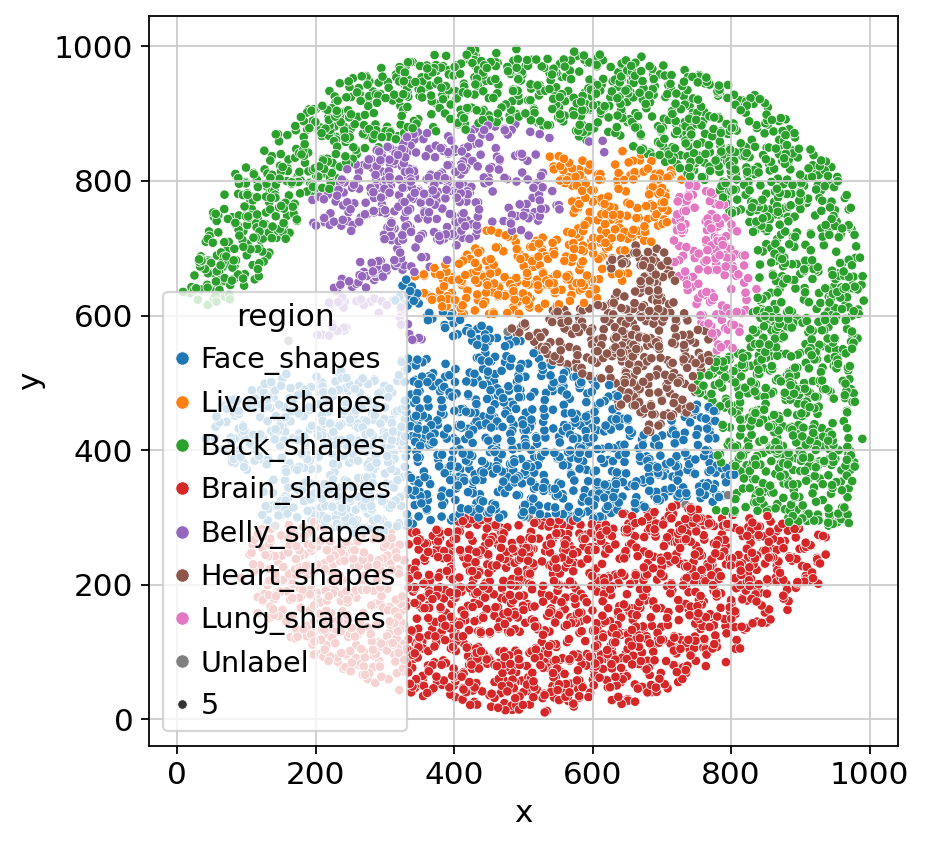

In [16]:
coordinates = pd.DataFrame(adata_ref.obsm['spatial'])
coordinates['region'] = list(adata_ref.obs['region'])
coordinates.columns = ['x', 'y', 'region']
sns.scatterplot(x="x", y="y", hue = 'region', size = 5, data=coordinates, palette="tab10")

In [17]:
# !pip install gseapy

In [18]:
from gseapy import Biomart
import pandas as pd

# Initialize Biomart
bm = Biomart()

# Query Ensembl for mouse-to-human gene mapping
m2h = bm.query(
    dataset='mmusculus_gene_ensembl',
    attributes=[
        'ensembl_gene_id', 
        'external_gene_name', 
        'hsapiens_homolog_ensembl_gene', 
        'hsapiens_homolog_associated_gene_name'
    ]
)

# Convert to DataFrame
m2h_df = pd.DataFrame(m2h)
m2h_df.columns = ['mouse_ensembl', 'mouse_gene', 'human_ensembl', 'human_gene']

In [19]:
# m2h_df.to_csv('/home/hpc/v138da/v138da11/scGPTfinetune/scGPT/data/mouse2humangenesconverter.csv')

In [20]:
# Ensure gene symbols in var_names
mouse_genes = adata_ref.var_names.tolist()
print(f"Number of genes in AnnData: {len(mouse_genes)}")
# Create mapping dictionary: {mouse_gene: human_gene}
mapping_dict = m2h_df.dropna(subset=['mouse_gene', 'human_gene']) \
                     .set_index('mouse_gene')['human_gene'].to_dict()
# Map var_names
human_genes = [mapping_dict.get(g, None) for g in mouse_genes]
# Add to AnnData
adata_ref.var['human_gene'] = human_genes
mask = adata_ref.var['human_gene'].notna()
adata_ref = adata_ref[:, mask].copy()

adata_target.var['human_gene'] = human_genes
adata_target.var_names = human_genes
adata_target = adata_target[:, mask].copy()
adata_target.var_names_make_unique()

Number of genes in AnnData: 27852


In [21]:
adata = adata_ref
adata.var['gene_name'] = adata.var['human_gene']
adata = SelfGraphConv(adata, n_neighbors = 4)

In [22]:
# test_data_idx = train_ids[0]
# adata_test = sc.read('/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/'+test_data_idx+'.h5ad')
# adata_test = adata_test[~adata_test.obs.Region.isna()].copy()
# adata_test = adata
# adata_test.var['gene_name'] = adata_test.var['human_gene']
# adata_test = SelfGraphConv(adata_test, n_neighbors = 4)
adata.var_names_make_unique()
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat_v3')
hvg_mask = adata.var['highly_variable']
hvg_genes = adata.var_names[hvg_mask]
adata = adata[:, hvg_genes]
# adata_test = adata_test[:, hvg_genes]

adata.obs["celltype"] = adata.obs["region"].astype("category")
# adata_test.obs["celltype"] = adata_test.obs["cluster"].astype("category")
adata.obs["batch_id"]  = adata.obs["str_batch"] = "0"
# adata_test.obs["batch_id"]  = adata_test.obs["str_batch"] = "1"          
adata.var.set_index(adata.var["gene_name"], inplace=True)
# adata_test.var.set_index(adata.var["gene_name"], inplace=True)
data_is_raw = False
filter_gene_by_counts = False
# adata_test_raw = adata_test.copy()
# adata = adata.concatenate(adata_test, batch_key="str_batch")
                
# make the batch category column
batch_id_labels = adata.obs["str_batch"].astype("category").cat.codes.values
adata.obs["batch_id"] = batch_id_labels
celltype_id_labels = adata.obs["celltype"].astype("category").cat.codes.values
celltypes = adata.obs["celltype"].unique()
num_types = len(np.unique(celltype_id_labels))
id2type = dict(enumerate(adata.obs["celltype"].astype("category").cat.categories))
adata.obs["celltype_id"] = celltype_id_labels
adata.var["gene_name"] = adata.var.index.tolist()

In [23]:
if config.load_model is not None:
    model_dir = Path(config.load_model)
    model_config_file = model_dir / "args.json"
    model_file = model_dir / "best_model.pt"
    vocab_file = model_dir / "vocab.json"

    vocab = GeneVocab.from_file(vocab_file)
    shutil.copy(vocab_file, save_dir / "vocab.json")
    for s in special_tokens:
        if s not in vocab:
            vocab.append_token(s)

    adata.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in adata.var["gene_name"]
    ]
    gene_ids_in_vocab = np.array(adata.var["id_in_vocab"])
    logger.info(
        f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
        f"in vocabulary of size {len(vocab)}."
    )
    adata = adata[:, adata.var["id_in_vocab"] >= 0]

    # model
    with open(model_config_file, "r") as f:
        model_configs = json.load(f)
    logger.info(
        f"Resume model from {model_file}, the model args will override the "
        f"config {model_config_file}."
    )
    embsize = model_configs["embsize"]
    nhead = model_configs["nheads"]
    d_hid = model_configs["d_hid"]
    nlayers = model_configs["nlayers"]
    n_layers_cls = model_configs["n_layers_cls"]

scGPT - INFO - match 2989/3000 genes in vocabulary of size 60697.
scGPT - INFO - Resume model from /home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human/best_model.pt, the model args will override the config /home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human/args.json.


In [24]:
adata

View of AnnData object with n_obs × n_vars = 6000 × 2989
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - AI987944', 'Brain_shapes', 'Face_shapes', 'Heart_shapes', 'Lung_shapes', 'Liver_shapes', 'Shapes_shapes', 'Belly_shapes', 'Back_shapes', 'region', 'celltype', 'batch_id', 'str_batch', 'celltype_id'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'human_gene', 'gene_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'id_in_vocab'
    uns: 'region_colors', 'hvg'
    obsm: 'spatial', 'spatial_back'
    varm: 'PCs'

In [25]:
# set up the preprocessor, use the args to config the workflow
preprocessor = Preprocessor(
    use_key="X",  # the key in adata.layers to use as raw data
    filter_gene_by_counts=filter_gene_by_counts,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=data_is_raw,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    subset_hvg=False,  # 5. whether to subset the raw data to highly variable genes
    hvg_flavor="seurat_v3" if data_is_raw else "cell_ranger",
    binning=n_bins,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
)


# adata_test = adata[adata.obs["str_batch"] == "1"]
# adata = adata[adata.obs["str_batch"] == "0"]

preprocessor(adata, batch_key=None)
# preprocessor(adata_test, batch_key=None)
adata_test = adata

scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Binning data ...


In [26]:
input_layer_key = {  # the values of this map coorespond to the keys in preprocessing
    "normed_raw": "X_normed",
    "log1p": "X_normed",
    "binned": "X_binned",
}[input_style]
all_counts = (
    adata.layers[input_layer_key].toarray()
    if issparse(adata.layers[input_layer_key])
    else adata.layers[input_layer_key]
)
genes = adata.var["gene_name"].tolist()

celltypes_labels = adata.obs["celltype_id"].tolist()  # make sure count from 0
celltypes_labels = np.array(celltypes_labels)

batch_ids = adata.obs["batch_id"].tolist()
num_batch_types = len(set(batch_ids))
batch_ids = np.array(batch_ids)

(
    train_data,
    valid_data,
    train_celltype_labels,
    valid_celltype_labels,
    train_batch_labels,
    valid_batch_labels,
) = train_test_split(
    all_counts, celltypes_labels, batch_ids, test_size=0.1, shuffle=True
)

In [27]:
if config.load_model is None:
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(vocab(genes), dtype=int)

In [28]:
tokenized_train = tokenize_and_pad_batch(
    train_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,  # append <cls> token at the beginning
    include_zero_gene=include_zero_gene,
)
tokenized_valid = tokenize_and_pad_batch(
    valid_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,
    include_zero_gene=include_zero_gene,
)
logger.info(
    f"train set number of samples: {tokenized_train['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_train['genes'].shape[1]}"
)
logger.info(
    f"valid set number of samples: {tokenized_valid['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_valid['genes'].shape[1]}"
)

scGPT - INFO - train set number of samples: 5400, 
	 feature length: 1416
scGPT - INFO - valid set number of samples: 600, 
	 feature length: 1314


In [29]:
def prepare_data(sort_seq_batch=False) -> Tuple[Dict[str, torch.Tensor]]:
    masked_values_train = random_mask_value(
        tokenized_train["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    masked_values_valid = random_mask_value(
        tokenized_valid["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    print(
        f"random masking at epoch {epoch:3d}, ratio of masked values in train: ",
        f"{(masked_values_train == mask_value).sum() / (masked_values_train - pad_value).count_nonzero():.4f}",
    )

    input_gene_ids_train, input_gene_ids_valid = (
        tokenized_train["genes"],
        tokenized_valid["genes"],
    )
    input_values_train, input_values_valid = masked_values_train, masked_values_valid
    target_values_train, target_values_valid = (
        tokenized_train["values"],
        tokenized_valid["values"],
    )

    tensor_batch_labels_train = torch.from_numpy(train_batch_labels).long()
    tensor_batch_labels_valid = torch.from_numpy(valid_batch_labels).long()

    tensor_celltype_labels_train = torch.from_numpy(train_celltype_labels).long()
    tensor_celltype_labels_valid = torch.from_numpy(valid_celltype_labels).long()

    if sort_seq_batch:  # TODO: update to random pick seq source in each traning batch
        train_sort_ids = np.argsort(train_batch_labels)
        input_gene_ids_train = input_gene_ids_train[train_sort_ids]
        input_values_train = input_values_train[train_sort_ids]
        target_values_train = target_values_train[train_sort_ids]
        tensor_batch_labels_train = tensor_batch_labels_train[train_sort_ids]
        tensor_celltype_labels_train = tensor_celltype_labels_train[train_sort_ids]

        valid_sort_ids = np.argsort(valid_batch_labels)
        input_gene_ids_valid = input_gene_ids_valid[valid_sort_ids]
        input_values_valid = input_values_valid[valid_sort_ids]
        target_values_valid = target_values_valid[valid_sort_ids]
        tensor_batch_labels_valid = tensor_batch_labels_valid[valid_sort_ids]
        tensor_celltype_labels_valid = tensor_celltype_labels_valid[valid_sort_ids]

    train_data_pt = {
        "gene_ids": input_gene_ids_train,
        "values": input_values_train,
        "target_values": target_values_train,
        "batch_labels": tensor_batch_labels_train,
        "celltype_labels": tensor_celltype_labels_train,
    }
    valid_data_pt = {
        "gene_ids": input_gene_ids_valid,
        "values": input_values_valid,
        "target_values": target_values_valid,
        "batch_labels": tensor_batch_labels_valid,
        "celltype_labels": tensor_celltype_labels_valid,
    }

    return train_data_pt, valid_data_pt


# dataset
class SeqDataset(Dataset):
    def __init__(self, data: Dict[str, torch.Tensor]):
        self.data = data

    def __len__(self):
        return self.data["gene_ids"].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items()}


# data_loader
def prepare_dataloader(
    data_pt: Dict[str, torch.Tensor],
    batch_size: int,
    shuffle: bool = False,
    intra_domain_shuffle: bool = False,
    drop_last: bool = False,
    num_workers: int = 0,
) -> DataLoader:
    if num_workers == 0:
        num_workers = min(len(os.sched_getaffinity(0)), batch_size // 2)

    dataset = SeqDataset(data_pt)

    if per_seq_batch_sample:
        # find the indices of samples in each seq batch
        subsets = []
        batch_labels_array = data_pt["batch_labels"].numpy()
        for batch_label in np.unique(batch_labels_array):
            batch_indices = np.where(batch_labels_array == batch_label)[0].tolist()
            subsets.append(batch_indices)
        data_loader = DataLoader(
            dataset=dataset,
            batch_sampler=SubsetsBatchSampler(
                subsets,
                batch_size,
                intra_subset_shuffle=intra_domain_shuffle,
                inter_subset_shuffle=shuffle,
                drop_last=drop_last,
            ),
            num_workers=num_workers,
            pin_memory=True,
        )
        return data_loader

    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
    )
    return data_loader


## Step 3: Load the pre-trained scGPT model

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ntokens = len(vocab)  # size of vocabulary
model = TransformerModel(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=3,
    n_cls=num_types if CLS else 1,
    vocab=vocab,
    dropout=dropout,
    pad_token=pad_token,
    pad_value=pad_value,
    do_mvc=MVC,
    do_dab=DAB,
    use_batch_labels=INPUT_BATCH_LABELS,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm=config.DSBN,
    input_emb_style=input_emb_style,
    n_input_bins=n_input_bins,
    cell_emb_style=cell_emb_style,
    mvc_decoder_style=mvc_decoder_style,
    ecs_threshold=ecs_threshold,
    explicit_zero_prob=explicit_zero_prob,
    use_fast_transformer=fast_transformer,
    fast_transformer_backend=fast_transformer_backend,
    pre_norm=config.pre_norm,
)
if config.load_model is not None:
    try:
        model.load_state_dict(torch.load(model_file))
        # logger.info(f"Loading all model params from {model_file}")
    except:
        # only load params that are in the model and match the size
        model_dict = model.state_dict()
        pretrained_dict = torch.load(model_file)
        pretrained_dict = {
            k: v
            for k, v in pretrained_dict.items()
            if k in model_dict and v.shape == model_dict[k].shape
        }
        # for k, v in pretrained_dict.items():
        #     logger.info(f"Loading params {k} with shape {v.shape}")
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)

pre_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

# Freeze all pre-decoder weights
for name, para in model.named_parameters():
    # print("-"*20)
    # print(f"name: {name}")
    if config.freeze and "encoder" in name and "transformer_encoder" not in name:
    # if config.freeze and "encoder" in name:
        # print(f"freezing weights for: {name}")
        para.requires_grad = False

post_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

logger.info(f"Total Pre freeze Params {(pre_freeze_param_count )}")
logger.info(f"Total Post freeze Params {(post_freeze_param_count )}")
wandb.log(
        {
            "info/pre_freeze_param_count": pre_freeze_param_count,
            "info/post_freeze_param_count": post_freeze_param_count,
        },
)

model.to(device)
wandb.watch(model)

if ADV:
    discriminator = AdversarialDiscriminator(
        d_model=embsize,
        n_cls=num_batch_types,
    ).to(device)

scGPT - INFO - Total Pre freeze Params 51335689
scGPT - INFO - Total Post freeze Params 19993097


In [31]:
device

device(type='cuda')

In [32]:
criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()
criterion_dab = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=lr, eps=1e-4 if config.amp else 1e-8
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, schedule_interval, gamma=config.schedule_ratio
)
if DAB_separate_optim:
    optimizer_dab = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler_dab = torch.optim.lr_scheduler.StepLR(
        optimizer_dab, schedule_interval, gamma=config.schedule_ratio
    )
if ADV:
    criterion_adv = nn.CrossEntropyLoss()  # consider using label smoothing
    optimizer_E = torch.optim.Adam(model.parameters(), lr=lr_ADV)
    scheduler_E = torch.optim.lr_scheduler.StepLR(
        optimizer_E, schedule_interval, gamma=config.schedule_ratio
    )
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_ADV)
    scheduler_D = torch.optim.lr_scheduler.StepLR(
        optimizer_D, schedule_interval, gamma=config.schedule_ratio
    )

scaler = torch.cuda.amp.GradScaler(enabled=config.amp)

In [33]:
def train(model: nn.Module, loader: DataLoader) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    (
        total_loss,
        total_mse,
        total_cls,
        total_cce,
        total_mvc,
        total_ecs,
        total_dab,
        total_adv_E,
        total_adv_D,
        total_zero_log_prob,
        total_mvc_zero_log_prob,
    ) = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    total_error = 0.0
    start_time = time.time()

    num_batches = len(loader)
    for batch, batch_data in enumerate(loader):
        input_gene_ids = batch_data["gene_ids"].to(device)
        input_values = batch_data["values"].to(device)
        target_values = batch_data["target_values"].to(device)
        batch_labels = batch_data["batch_labels"].to(device)
        celltype_labels = batch_data["celltype_labels"].to(device)

        src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
        with torch.cuda.amp.autocast(enabled=config.amp):
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            masked_positions = input_values.eq(mask_value)  # the postions to predict
            loss = 0.0
            metrics_to_log = {}
            if MLM:
                loss_mse = criterion(
                    output_dict["mlm_output"], target_values, masked_positions
                )
                loss = loss + loss_mse
                metrics_to_log = {"train/mse": loss_mse.item()}
            if explicit_zero_prob:
                loss_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mlm_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_zero_log_prob
                metrics_to_log.update({"train/nzlp": loss_zero_log_prob.item()})
            if CLS:
                loss_cls = criterion_cls(output_dict["cls_output"], celltype_labels)
                loss = loss + loss_cls
                metrics_to_log.update({"train/cls": loss_cls.item()})

                error_rate = 1 - (
                    (output_dict["cls_output"].argmax(1) == celltype_labels)
                    .sum()
                    .item()
                ) / celltype_labels.size(0)
            if CCE:
                loss_cce = 10 * output_dict["loss_cce"]
                loss = loss + loss_cce
                metrics_to_log.update({"train/cce": loss_cce.item()})
            if MVC:
                loss_mvc = criterion(
                    output_dict["mvc_output"], target_values, masked_positions
                )
                loss = loss + loss_mvc
                metrics_to_log.update({"train/mvc": loss_mvc.item()})
            if MVC and explicit_zero_prob:
                loss_mvc_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mvc_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_mvc_zero_log_prob
                metrics_to_log.update({"train/mvc_nzlp": loss_mvc_zero_log_prob.item()})
            if ECS:
                loss_ecs = 10 * output_dict["loss_ecs"]
                loss = loss + loss_ecs
                metrics_to_log.update({"train/ecs": loss_ecs.item()})
            if DAB:
                # try weighting and separate optimizer
                loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)
                loss = loss + dab_weight * loss_dab
                metrics_to_log.update({"train/dab": loss_dab.item()})

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                logger.warning(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )
        scaler.step(optimizer)
        scaler.update()

        if ADV:
            # rerun the model for adversarial training
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            # TRAINING DISCRIMINATOR
            loss_adv_D = criterion_adv(
                discriminator(output_dict["cell_emb"].detach()), batch_labels
            )
            if epoch > adv_D_delay_epochs:
                discriminator.zero_grad()
                loss_adv_D.backward()
                optimizer_D.step()

            # TRAINING ENCODER
            loss_adv_E = -criterion_adv(
                discriminator(output_dict["cell_emb"]), batch_labels
            )
            # NOTE: the loss is negative here because we want to maximize
            # the cross_entropy_loss, in other words, disguise against the discriminator
            if epoch > adv_E_delay_epochs:
                model.zero_grad()
                discriminator.zero_grad()
                loss_adv_E.backward()
                optimizer_E.step()

        wandb.log(metrics_to_log)

        total_loss += loss.item()
        total_mse += loss_mse.item() if MLM else 0.0
        total_cls += loss_cls.item() if CLS else 0.0
        total_cce += loss_cce.item() if CCE else 0.0
        total_mvc += loss_mvc.item() if MVC else 0.0
        total_ecs += loss_ecs.item() if ECS else 0.0
        total_dab += loss_dab.item() if DAB else 0.0
        total_adv_E += loss_adv_E.item() if ADV else 0.0
        total_adv_D += loss_adv_D.item() if ADV else 0.0
        total_zero_log_prob += loss_zero_log_prob.item() if explicit_zero_prob else 0.0
        total_mvc_zero_log_prob += (
            loss_mvc_zero_log_prob.item() if MVC and explicit_zero_prob else 0.0
        )
        total_error += error_rate
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            cur_cls = total_cls / log_interval if CLS else 0.0
            cur_cce = total_cce / log_interval if CCE else 0.0
            cur_mvc = total_mvc / log_interval if MVC else 0.0
            cur_ecs = total_ecs / log_interval if ECS else 0.0
            cur_dab = total_dab / log_interval if DAB else 0.0
            cur_adv_E = total_adv_E / log_interval if ADV else 0.0
            cur_adv_D = total_adv_D / log_interval if ADV else 0.0
            cur_zero_log_prob = (
                total_zero_log_prob / log_interval if explicit_zero_prob else 0.0
            )
            cur_mvc_zero_log_prob = (
                total_mvc_zero_log_prob / log_interval
                if MVC and explicit_zero_prob
                else 0.0
            )
            cur_error = total_error / log_interval
            # ppl = math.exp(cur_loss)
            logger.info(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | "
                + (f"mse {cur_mse:5.2f} | mre {cur_error:5.2f} |" if MLM else "")
                + (f"cls {cur_cls:5.2f} | " if CLS else "")
                + (f"err {cur_error:5.2f} | " if CLS else "")
                + (f"cce {cur_cce:5.2f} |" if CCE else "")
                + (f"mvc {cur_mvc:5.2f} |" if MVC else "")
                + (f"ecs {cur_ecs:5.2f} |" if ECS else "")
                + (f"dab {cur_dab:5.2f} |" if DAB else "")
                + (f"adv_E {cur_adv_E:5.2f} |" if ADV else "")
                + (f"adv_D {cur_adv_D:5.2f} |" if ADV else "")
                + (f"nzlp {cur_zero_log_prob:5.2f} |" if explicit_zero_prob else "")
                + (
                    f"mvc_nzlp {cur_mvc_zero_log_prob:5.2f} |"
                    if MVC and explicit_zero_prob
                    else ""
                )
            )
            total_loss = 0
            total_mse = 0
            total_cls = 0
            total_cce = 0
            total_mvc = 0
            total_ecs = 0
            total_dab = 0
            total_adv_E = 0
            total_adv_D = 0
            total_zero_log_prob = 0
            total_mvc_zero_log_prob = 0
            total_error = 0
            start_time = time.time()


def define_wandb_metrcis():
    wandb.define_metric("valid/mse", summary="min", step_metric="epoch")
    wandb.define_metric("valid/mre", summary="min", step_metric="epoch")
    wandb.define_metric("valid/dab", summary="min", step_metric="epoch")
    wandb.define_metric("valid/sum_mse_dab", summary="min", step_metric="epoch")
    wandb.define_metric("test/avg_bio", summary="max")


def evaluate(model: nn.Module, loader: DataLoader, return_raw: bool = False) -> float:
    """
    Evaluate the model on the evaluation data.
    """
    model.eval()
    total_loss = 0.0
    total_error = 0.0
    total_dab = 0.0
    total_num = 0
    predictions = []
    embed_vec = []
    with torch.no_grad():
        for batch_data in loader:
            input_gene_ids = batch_data["gene_ids"].to(device)
            input_values = batch_data["values"].to(device)
            target_values = batch_data["target_values"].to(device)
            batch_labels = batch_data["batch_labels"].to(device)
            celltype_labels = batch_data["celltype_labels"].to(device)

            src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
            with torch.cuda.amp.autocast(enabled=config.amp):
                output_dict = model(
                    input_gene_ids,
                    input_values,
                    src_key_padding_mask=src_key_padding_mask,
                    batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                    CLS=CLS,  # evaluation does not need CLS or CCE
                    CCE=False,
                    MVC=False,
                    ECS=False,
                    do_sample=do_sample_in_train,
                    #generative_training = False,
                )
                output_values = output_dict["cls_output"]
                loss = criterion_cls(output_values, celltype_labels)
                
                embed_vec.append(output_dict['cell_emb'].cpu().numpy())

                if DAB:
                    loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)

            total_loss += loss.item() * len(input_gene_ids)
            accuracy = (output_values.argmax(1) == celltype_labels).sum().item()
            total_error += (1 - accuracy / len(input_gene_ids)) * len(input_gene_ids)
            total_dab += loss_dab.item() * len(input_gene_ids) if DAB else 0.0
            total_num += len(input_gene_ids)
            preds = output_values.argmax(1).cpu().numpy()
            predictions.append(preds)

    wandb.log(
        {
            "valid/mse": total_loss / total_num,
            "valid/err": total_error / total_num,
            "valid/dab": total_dab / total_num,
            "valid/sum_mse_dab": (total_loss + dab_weight * total_dab) / total_num,
            "epoch": epoch,
        },
    )

    if return_raw:
        return np.concatenate(predictions, axis=0), np.concatenate(embed_vec, axis=0)

    return total_loss / total_num, total_error / total_num


## Step 4: Finetune scGPT with task-specific objectives

In [34]:
best_val_loss = float("inf")
best_avg_bio = 0.0
best_model = None
define_wandb_metrcis()

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_data_pt, valid_data_pt = prepare_data(sort_seq_batch=per_seq_batch_sample)
    train_loader = prepare_dataloader(
        train_data_pt,
        batch_size=batch_size,
        shuffle=False,
        intra_domain_shuffle=True,
        drop_last=False,
    )
    valid_loader = prepare_dataloader(
        valid_data_pt,
        batch_size=eval_batch_size,
        shuffle=False,
        intra_domain_shuffle=False,
        drop_last=False,
    )

    if config.do_train:
        train(
            model,
            loader=train_loader,
        )
    val_loss, val_err = evaluate(
        model,
        loader=valid_loader,
    )
    elapsed = time.time() - epoch_start_time
    logger.info("-" * 89)
    logger.info(
        f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | "
        f"valid loss/mse {val_loss:5.4f} | err {val_err:5.4f}"
    )
    logger.info("-" * 89)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model)
        best_model_epoch = epoch
        logger.info(f"Best model with score {best_val_loss:5.4f}")

    scheduler.step()
    if DAB_separate_optim:
        scheduler_dab.step()
    if ADV:
        scheduler_D.step()
        scheduler_E.step()

random masking at epoch   1, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   1 | 100/338 batches | lr 0.0001 | ms/batch 156.98 | loss  1.74 | cls  1.74 | err  0.72 | 
scGPT - INFO - | epoch   1 | 200/338 batches | lr 0.0001 | ms/batch 147.61 | loss  1.63 | cls  1.63 | err  0.67 | 
scGPT - INFO - | epoch   1 | 300/338 batches | lr 0.0001 | ms/batch 147.61 | loss  1.29 | cls  1.29 | err  0.52 | 
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - | end of epoch   1 | time: 52.80s | valid loss/mse 1.2003 | err 0.4917
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - Best model with score 1.2003
random masking at epoch   2, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   2 | 100/338 batches | lr 0.0001 | ms/batch 150.94 | loss  1.08 | cls  1.08 | err  0.46 | 
scGPT - INFO - | epoch   2 | 200/338 batches | lr 0.0001 | m

In [35]:
# %% inference
def test(model: nn.Module, adata: DataLoader) -> float:
    all_counts = (
        adata.layers[input_layer_key].toarray()
        if issparse(adata.layers[input_layer_key])
        else adata.layers[input_layer_key]
    )

    celltypes_labels = adata.obs["celltype_id"].tolist()  # make sure count from 0
    celltypes_labels = np.array(celltypes_labels)

    batch_ids = adata.obs["batch_id"].tolist()
    batch_ids = np.array(batch_ids)

    tokenized_test = tokenize_and_pad_batch(
        all_counts,
        gene_ids,
        max_len=max_seq_len,
        vocab=vocab,
        pad_token=pad_token,
        pad_value=pad_value,
        append_cls=True,  # append <cls> token at the beginning
        include_zero_gene=include_zero_gene,
    )

    input_values_test = random_mask_value(
        tokenized_test["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )

    test_data_pt = {
        "gene_ids": tokenized_test["genes"],
        "values": input_values_test,
        "target_values": tokenized_test["values"],
        "batch_labels": torch.from_numpy(batch_ids).long(),
        "celltype_labels": torch.from_numpy(celltypes_labels).long(),
    }

    test_loader = DataLoader(
        dataset=SeqDataset(test_data_pt),
        batch_size=eval_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=min(len(os.sched_getaffinity(0)), eval_batch_size // 2),
        pin_memory=True,
    )

    model.eval()
    predictions, embed = evaluate(
        model,
        loader=test_loader,
        return_raw=True,
    )

    # compute accuracy, precision, recall, f1
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    accuracy = accuracy_score(celltypes_labels, predictions)
    precision = precision_score(celltypes_labels, predictions, average="macro")
    recall = recall_score(celltypes_labels, predictions, average="macro")
    macro_f1 = f1_score(celltypes_labels, predictions, average="macro")

    logger.info(
        f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, "
        f"Macro F1: {macro_f1:.3f}"
    )

    results = {
        "test/accuracy": accuracy,
        "test/precision": precision,
        "test/recall": recall,
        "test/macro_f1": macro_f1,
    }

    return predictions, celltypes_labels, results, embed

## Step 5: Inference with fine-tuned scGPT model
In the cell-type annotation task, the fine-tuned scGPT predicts cell-type labels for query set as inference. The model performance is evaluated on standard classificaton metrics. Here we visualize the predicted labels over the scGPT cell embeddings, and present the confusion matrix for detailed classification performance on the cell-group level.

In [36]:
import torch
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import coo_matrix
from torch_geometric.utils import to_undirected
def to_edge_index(adata, n_neighbors: int = 4, self_loops: bool = False) -> torch.Tensor:
    """
    Convert a feature matrix X into PyG edge_index using kNN.  
    Args:
        adata: 
        k (int): Number of neighbors
        self_loops (bool): Whether to include self-loops
    
    Returns:
        edge_index (torch.LongTensor): Shape [2, num_edges]
    """
    spatial_coords = adata.obsm["spatial"]
    # Step 1: Build sparse adjacency matrix (kNN graph)
    adj = kneighbors_graph(spatial_coords, n_neighbors=n_neighbors, include_self=False)
    # Step 2: Convert sparse matrix to COO format
    adj_coo = coo_matrix(adj)
    # Step 3: Build edge_index from COO (rows = source, cols = target)
    edge_index = torch.tensor(
        [adj_coo.row, adj_coo.col],
        dtype=torch.long
    )    
    edge_index = to_undirected(edge_index)
    return edge_index

def perform_inference(best_model, adata_test2):
    # adata_test2 = adata_test2[~adata_test2.obs.Region.isna()].copy()
    adata_test2 = SelfGraphConv(adata_test2, n_neighbors = 4)
    adata_test2 = adata_test2[:, adata.var_names]
    adata_test2.obs["celltype"] = adata_test2.obs["region"].astype("category")
    # adata_test2.obs["celltype_id"] = adata_test2.obs["celltype"].astype("category").cat.codes.values
    test_labels = np.array(list(adata_test2.obs["region"]))
    all_labels = np.unique(test_labels)
    all_labels_sorted = np.sort(all_labels)
    label_to_id = {label: i for i, label in enumerate(all_labels_sorted)}
    all_labels_int = np.array([label_to_id[l] for l in test_labels])
    adata_test2.obs["celltype_id"]  = all_labels_int
    adata_test2.var["gene_name"] = adata_test2.var.index.tolist()
    adata_test2.obs["batch_id"]  = np.array([1]*adata_test2.shape[0]).astype('int8')
    preprocessor(adata_test2, batch_key=None)
    predictions, labels, results, emb = test(best_model, adata_test2)
    return  predictions, labels, results, emb

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [38]:
# train_data_idx

In [39]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
adata_train = adata
#predictions, labels_train, results, emb_train = perform_inference(best_model, adata_train)
adata_train.var_names_make_unique()
predictions, labels_train, results, emb_train = perform_inference(model, adata_train)

scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Binning data ...
scGPT - INFO - Accuracy: 0.957, Precision: 0.823, Recall: 0.832, Macro F1: 0.826


In [40]:
# input_gene_ids_train

In [41]:
# 1. Create training graph (100 nodes)
n_features = emb_train.shape[1]
x_train = torch.tensor(emb_train, dtype=torch.float)           # features
y_train = torch.tensor(labels_train, dtype=torch.long)         # class labels
n_classes = len(set(y_train))
edge_index_train = to_edge_index(adata_train, 4)
train_graph = Data(x=x_train, edge_index=edge_index_train, y=y_train)

# 3. Define a simple GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x
    
from torch_geometric.nn import APPNP
class APPNPNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=10, alpha=0.1):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        x = F.relu(self.lin1(x))
        x = self.lin2(x)
        x = self.prop(x, edge_index)
        return x

In [42]:
# Classic model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnnmodel = APPNPNet(in_channels=n_features, hidden_channels=16, out_channels=n_classes).to(device)
optimizer = torch.optim.Adam(gnnmodel.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_graph = train_graph.to(device)

# 5. Training loop (on full training graph)
def train():
    gnnmodel.train()
    optimizer.zero_grad()
    out = gnnmodel(train_graph.x, train_graph.edge_index)
    loss = criterion(out, train_graph.y)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate_gnn(data):
    model.eval()
    out = gnnmodel(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred == data.y).sum().item() / data.y.size(0)
    # pred = pred.cpu().numpy()
    return acc, pred

# 6. Run training
for epoch in range(180):
    loss = train()
    train_acc, _ = evaluate_gnn(train_graph)
    if (epoch % 20) == 0:
        print(f"Epoch {epoch:02d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}")


Epoch 00, Loss: 8.7498, Train Acc: 0.0000
Epoch 20, Loss: 4.3279, Train Acc: 0.6017
Epoch 40, Loss: 0.9969, Train Acc: 0.9265
Epoch 60, Loss: 0.2222, Train Acc: 0.9508
Epoch 80, Loss: 0.1282, Train Acc: 0.9742
Epoch 100, Loss: 0.1075, Train Acc: 0.9760
Epoch 120, Loss: 0.0974, Train Acc: 0.9765
Epoch 140, Loss: 0.0904, Train Acc: 0.9765
Epoch 160, Loss: 0.0850, Train Acc: 0.9777


In [ ]:
# adata_test2 = adata_test[:, common_genes].copy()
#predictions, labels_test, results, emb_test = perform_inference(best_model, adata_test2)
adata_test2 = adata_target#.copy()
adata_test2.var_names_make_unique()
#adata_test2.obs['cluster'] = [1]*adata_test2.shape[0]
adata_test2.obs['cluster'] = adata_test2.obs['region']
predictions, labels_test, results, emb_test = perform_inference(model, adata_test2)
y_pred = cKD_refine_label(np.array(adata_test2.obsm['spatial']), predictions, k = 50)

In [ ]:
df = pd.DataFrame({'y_true': labels_test, 'y_pred': y_pred})
df.to_csv('output/hen-Stereo_seq_stGPTNet.csv', index=False)